In [27]:
# ==============================================================================
# CELL 1: SETUP IMPORTS AND PATHS
# ==============================================================================
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# Define your exact paths
MODEL_PATH = "max_efficiency_cocoa_model.keras"
# Replace 'your_image.jpg' with the actual filename inside your test directory
IMAGE_PATH = r"D:\test_images\TestSamples\test_2.jpg" 

# Class labels mapped exactly to your training setup order
CLASS_NAMES = ['Anthracnose', 'CSSVD', 'Healthy', 'Monilia', 'Phytophthora', 'PodBorer']

print(f"[INFO] Target Image: {IMAGE_PATH}")
if not os.path.exists(IMAGE_PATH):
    print("[WARNING] Please check your filename! The path specified does not exist yet.")

[INFO] Target Image: D:\test_images\TestSamples\test_2.jpg


[INFO] Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


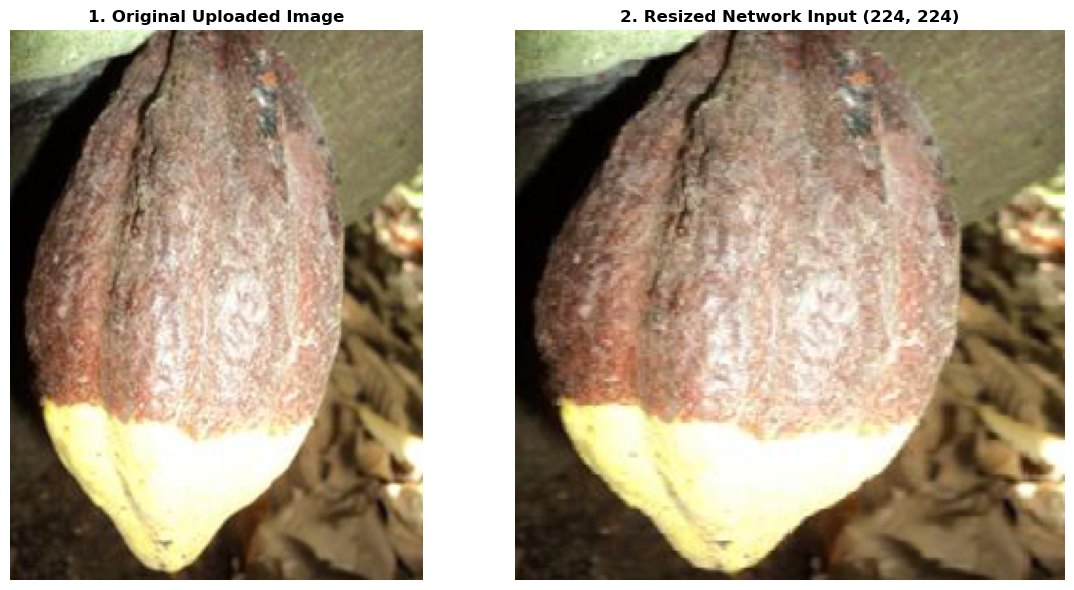


             INFERENCE RESULT             
Predicted Class    :  Healthy
Confidence Score   :  71.38%

[INFO] Full probability breakdown across classes:
 -> Anthracnose    :   9.38%
 -> CSSVD          :   5.40%
 -> Healthy        :  71.38%
 -> Monilia        :   0.28%
 -> Phytophthora   :  12.39%
 -> PodBorer       :   1.17%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

[WARNING] Pod appears healthy, but showing secondary traces of: Phytophthora


In [28]:
# ==============================================================================
# CELL 2: LOAD, PREPROCESS, PREDICT, AND DISPLAY (CORRECTED)
# ==============================================================================
# 1. Load the model safely from disk
if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)
    print("[INFO] Model loaded successfully.")
else:
    raise FileNotFoundError(f"Could not find model file at {MODEL_PATH}")

# 2. Load the original full-sized image for visualization
original_img = load_img(IMAGE_PATH)

# 3. Load and resize the image specifically for EfficientNetV2B0 input sizes
target_size = (224, 224)
resized_img = load_img(IMAGE_PATH, target_size=target_size)

# 4. Convert image to numpy array format
img_array = img_to_array(resized_img)

# 5. Expand dimensions to create batch form: (224, 224, 3) -> (1, 224, 224, 3)
img_batch = np.expand_dims(img_array, axis=0)

# 6. Apply standard ImageNet scaling normalization
preprocessed_batch = preprocess_input(img_batch)

# 7. Execute model inference calculation matrices
predictions = model.predict(preprocessed_batch)
highest_conf_idx = np.argmax(predictions[0])
predicted_class = CLASS_NAMES[highest_conf_idx]
confidence_score = predictions[0][highest_conf_idx] * 100

# ------------------------------------------------------------------------------
# VISUALIZATION PLATFORM
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Original Sample View
axes[0].imshow(original_img)
axes[0].set_title("1. Original Uploaded Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Resized Network Input View
# FIX: Convert the float array safely back to standard 8-bit integers for the screen
viz_img = img_array.astype('uint8')
axes[1].imshow(viz_img)
axes[1].set_title(f"2. Resized Network Input {target_size}", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show() # FIX: Corrected typo from showim()

# ------------------------------------------------------------------------------
# PRINT FINAL METRIC TERMINAL OUTPUT
# ------------------------------------------------------------------------------
print("\n" + "="*40)
print("             INFERENCE RESULT             ")
print("="*40)
print(f"Predicted Class    :  {predicted_class}")
print(f"Confidence Score   :  {confidence_score:.2f}%")
print("="*40)

# Print a breakdown of all individual probabilities for verification
print("\n[INFO] Full probability breakdown across classes:")
for name, prob in zip(CLASS_NAMES, predictions[0]):
    print(f" -> {name:<15}: {prob*100:6.2f}%")


# 7. Execute model inference calculation matrices
predictions = model.predict(preprocessed_batch)
highest_conf_idx = np.argmax(predictions[0])
predicted_class = CLASS_NAMES[highest_conf_idx]
confidence_score = predictions[0][highest_conf_idx] * 100

# ==============================================================================
# THE SAFETY THRESHOLD FIX
# ==============================================================================
# If the model says Healthy, but isn't highly confident, trigger a warning.
if predicted_class == "Healthy" and confidence_score < 85.0:
    predicted_class = "⚠️ Uncertain (Manual Inspection Required)"
    
    # Optional: Find the highest probability disease to show what it might be
    disease_probs = predictions[0].copy()
    disease_probs[CLASS_NAMES.index("Healthy")] = 0 # Ignore healthy score
    second_guess_idx = np.argmax(disease_probs)
    second_guess_class = CLASS_NAMES[second_guess_idx]
    
    print(f"\n[WARNING] Pod appears healthy, but showing secondary traces of: {second_guess_class}")
# ==============================================================================